# **INFERENCIA ESTADÍSTICA**

________________________________

## **TALLER 1**

---
### **Instrucciones**

1. Duración: 70 minutos.
1. Lea detenidamente el enunciado y las preguntas.
1. Todas las respuestas deben estar justificadas y su desarrollo debe presentarse de manera ordenada y clara, de lo contrario es su responsabilidad si la pregunta no es corregida.
1. Se sugiere usar una o más celdas de código para el desarrollo y luego una celda de texto (markdown) para escribir la respuesta.
1. Este taller tiene 100 puntos y será evaluado con una pauta, con un porcentaje de exigencia del 60%. Por lo que la nota mínima de aprobación (4,0) se obtiene con 60 puntos y la nota máxima (7,0) con 100 puntos.
1. Guarde su progreso constantemente y verifique que todas las celdas de código hayan sido ejecutadas antes de la entrega.
1. El desarrollo debe ser entregado a su docente mediante el AVA de la asignatura en formato .ipynb.
1. **Prohibición de IA:** Durante esta evaluación está prohibido usar herramientas de inteligencia artificial o reescritura (p. ej., ChatGPT, Gemini, Grok, Copilot, QuillBot, traductores con mejora de estilo, asistentes de código). El uso no autorizado anula la respuesta y puede implicar sanciones según el reglamento. En caso de duda, el/la docente podrá solicitar verificación oral o repetir parte de la prueba.
1. Según el artículo N°38 del Reglamento Académico: Todo acto realizado por un/a estudiante que vicie una situación evaluativa, será sancionado con el término inmediato de la actividad y con la aplicación de la nota mínima (1,0). El/la docente de la asignatura entregará los antecedentes a la Dirección de Carrera o Subdirección Académica de la Sede para efectos de lo dispuesto en el Título XXI.
---

### **Integrantes**

**Estudiante 1:** (César Rojas Ramos)

**Estudiante 2:** (Lucas Moncada Espinoza)

**Estudiante 3:** (Ignacio Silva Carvajal)

**Sección:** (002D)

---

### **ANÁLISIS DE EFICIENCIA LOGÍSTICA**

**Contexto del Negocio:** Ustedes son el equipo Data Science de "FastLogistics SA". La gerencia operativa está preocupada por la variabilidad en los tiempos de entrega y el cumplimiento de los acuerdos de nivel de servicio (SLA).

Se les ha entregado una base de datos poblacional masiva. Su misión es validar hipótesis estadísticas utilizando técnicas de inferencia vistas en clase (Distribuciones Muestrales, Intervalos de Confianza para Media y Proporción).

Para descargar la base de datos haz clic **[aquí](https://drive.google.com/uc?export=download&id=1Of1X_ahfUgkrl9XOCfMsv_LnbrspIecF)**.
__________________

### **IMPORTACIÓN DE LIBRERÍAS**


Importen aquí todas las librerías que utilizarán para el desarrollo de la problemática

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

_____________________

### **PREGUNTA 1**


**El Fenómeno de la Distribución Muestral (30 Puntos)**

La población de tiempos de entrega no sigue una distribución normal (está sesgada), por lo que al graficarla no genera una campana esperada para una distribución normal. ¿Ocurrirá lo mismo con un conjunto de promedios muestrales de los tiempos de entrega?

**1) Lectura de datos:** Lee los datos poblacionales presentes en la hoja "Problema_1" de tu base de datos. (3 puntos)

In [20]:
df = pd.read_excel('T1_B1_data_logistica.xlsx', sheet_name='Problema_1')
df

,id_pedido,tiempo_entrega,retraso
0,1,57.45,0
1,2,35.87,0
2,3,33.17,0
3,4,33.18,0
4,5,111.59,0
...,...,...,...
49995,49996,111.33,0
49996,49997,49.21,0
49997,49998,24.65,0
49998,49999,15.41,0


**2) Simulación:** Extraigan 500 muestras aleatorias simples de tamaño $n=50$ de la variable "tiempo_entrega" (sin reposición). Calculen y guarden el promedio de cada muestra. (12 puntos)



In [14]:
import pandas as pd

np.random.seed(2026)

medias_tiempo_entrega = []

for i in range(500):
    muestra = np.random.choice(df['tiempo_entrega'], size=50, replace=False)
    medias_tiempo_entrega.append(np.mean(muestra))

medias_tiempo_entrega

[np.float64(50.57320000000001),
 np.float64(48.6628),
 np.float64(44.409000000000006),
 np.float64(52.043800000000005),
 np.float64(52.8226),
 np.float64(53.398799999999994),
 np.float64(42.39040000000001),
 np.float64(53.0168),
 np.float64(49.1426),
 np.float64(44.5554),
 np.float64(51.5128),
 np.float64(52.17759999999999),
 np.float64(51.86860000000001),
 np.float64(55.145999999999994),
 np.float64(42.733000000000004),
 np.float64(43.491800000000005),
 np.float64(50.28579999999999),
 np.float64(45.69200000000001),
 np.float64(48.4916),
 np.float64(39.5668),
 np.float64(48.5572),
 np.float64(43.4862),
 np.float64(44.07860000000001),
 np.float64(50.7976),
 np.float64(45.427800000000005),
 np.float64(50.679799999999986),
 np.float64(47.8776),
 np.float64(52.7592),
 np.float64(50.863200000000006),
 np.float64(47.39860000000001),
 np.float64(52.60320000000001),
 np.float64(41.348800000000004),
 np.float64(47.856400000000015),
 np.float64(46.552400000000006),
 np.float64(47.9186),
 np.floa

**3) Visualización:** Grafiquen el histograma de las medias muestrales del punto anterior. (8 puntos)



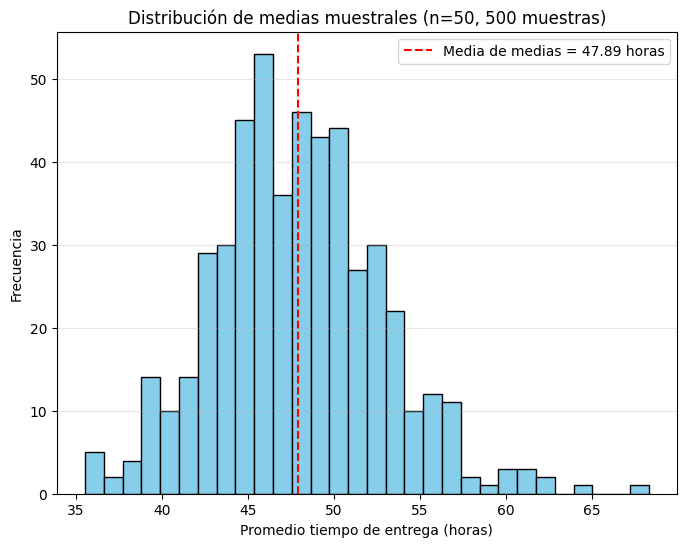

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(medias_tiempo_entrega, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.mean(medias_tiempo_entrega), color='red', linestyle='--',
            label=f'Media de medias = {np.mean(medias_tiempo_entrega):.2f} horas')
plt.title('Distribución de medias muestrales (n=50, 500 muestras)')
plt.xlabel('Promedio tiempo de entrega (horas)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

**4) Conclusión:** ¿Por qué la distribución de promedios se parece a una campana aunque la población no lo sea? Expliquen y justifiquen. (7 puntos)

La distribución se parece a una campana debido al Teorema Central del Límite (TCL), que establece que sin importar la forma de la distribución original de la población, la distribución de las medias muestrales se aproxima a una normal cuando el tamaño muestral es suficientemente grande.
En este caso, con n=50 por muestra y 500 repeticiones, se cumplen las condiciones del TCL. Esto se refleja en el histograma, donde los promedios se concentran alrededor de ~47-48 horas con poca dispersión hacia los extremos, tal como predice el error estándar a mayor n, menor dispersión de las medias.

______________________________

### **PREGUNTA 2:**


**Intervalos de Confianza para la Media (30 Puntos)**

La empresa promete, como máximo, un tiempo promedio de entrega de 60 horas.

**1) Lectura de datos muestrales:** Para comenzar el análisis en torno a la promesa de la empresa, deben leer los datos muestrales presentes en la hoja "Problema_2" de tu base de datos. (3 puntos)

In [21]:
df_muestra = pd.read_excel('T1_B1_data_logistica.xlsx', sheet_name='Problema_2')
df_muestra.head(10)

print(f"Tamaño de muestra (n): {len(df_muestra)}")
print(f"Media muestral: {df_muestra['tiempo_entrega'].mean():.4f} horas")
print(f"Desviación estándar muestral: {df_muestra['tiempo_entrega'].std(ddof=1):.4f} horas")

Tamaño de muestra (n): 100
Media muestral: 51.0672 horas
Desviación estándar muestral: 39.6990 horas


**2) Insumos estadísticos (etapa 1):** Construyan un intervalo de confianza al 95% para la media poblacional de los tiempos de entrega, considerando la muestra del punto anterior (usen distribución t-student). (20 puntos)

In [22]:
# Insumos estadísticos necesarios
n = len(df_muestra)
media = df_muestra['tiempo_entrega'].mean()
s = df_muestra['tiempo_entrega'].std(ddof=1)  # desviación estándar muestral

print(f"Tamaño de muestra (n): {n}")
print(f"Media muestral (x̄): {media:.4f} horas")
print(f"Desviación estándar muestral (s): {s:.4f} horas")
print(f"Error estándar (SE): {s/np.sqrt(n):.4f} horas")

# Construcción del intervalo de confianza al 95% con t-Student
ic = st.t.interval(
    confidence=0.95,   # Nivel de confianza
    df=n-1,            # Grados de libertad (n-1 = 99)
    loc=media,         # Media muestral
    scale=s/np.sqrt(n) # Error estándar
)

print(f"\nIC 95%: ({ic[0]:.4f} , {ic[1]:.4f}) horas")
print(f"Amplitud del intervalo: {ic[1] - ic[0]:.4f} horas")

Tamaño de muestra (n): 100
Media muestral (x̄): 51.0672 horas
Desviación estándar muestral (s): 39.6990 horas
Error estándar (SE): 3.9699 horas

IC 95%: (43.1901 , 58.9443) horas
Amplitud del intervalo: 15.7543 horas


**3) Análisis de la información y Conclusión:** A partir de lo obtenido, ¿la empresa estaría cumpliendo su promesa? Expliquen y justifiquen. (7 puntos)



- **El intervalo de confianza al 95% para el tiempo promedio de entrega resultó ser (43.19 , 58.94) horas, lo que significa que de cada 100 intervalos construidos con muestras del mismo tamaño, 95 de ellos contendrán al verdadero tiempo promedio de entrega poblacional. Cabe destacar que existe un margen de error del 5%, es decir, hay un 5% de probabilidad de que el intervalo construido no contenga la verdadera media poblacional.**

- **Dado que el límite superior del intervalo (58.94 horas) es menor que las 60 horas prometidas, el intervalo completo se encuentra por debajo del máximo comprometido por la empresa. Por lo tanto, con un 95% de confianza, se concluye que el tiempo promedio de entrega poblacional no supera las 60 horas, lo que indica que la empresa sí estaría cumpliendo su promesa.**

____________________________

### **PREGUNTA 3:**


**Intervalos de Confianza para la Proporción (40 Puntos)**

Norma de calidad: Máximo 20% de retrasos. Compare dos escenarios de muestreo:
- Escenario A: Muestra pequeña ($n=50$).
- Escenario B: Muestra grande ($n=1000$).

**1) Lectura de datos muestrales (de ambos escenarios):** Para comenzar el análisis en torno a la norma de calidad, deben leer los datos muestrales del escenario A presentes en la hoja "Problema_3A" de tu base de datos, y a continuación  los del escenario B presentes en la hoja "Problema_3B". (4 puntos)

In [16]:
df3a = pd.read_excel("T1_B1_data_logistica.xlsx", sheet_name="Problema_3A")
df3b = pd.read_excel("T1_B1_data_logistica.xlsx", sheet_name="Problema_3B")

print(f"Escenario A: {len(df3a)} observaciones")
print(f"Escenario B: {len(df3b)} observaciones")

Escenario A: 50 observaciones
Escenario B: 1000 observaciones


**2) Insumos estadísticos (Escenario A):** Calculen el IC al 95% para la proporción de retrasos del Escenario A. (14 puntos)

In [23]:
n_a = len(df3a)
p_a = df3a["retraso"].mean()

print("Escenario A — Verificación aproximación normal:")
print(f"  n·p̂     = {n_a}·{p_a:.4f} = {n_a*p_a:.2f} ≥ 10 → {'✓ Se cumple' if n_a*p_a >= 10 else '✗ No se cumple'}")
print(f"  n·(1-p̂) = {n_a}·{1-p_a:.4f} = {n_a*(1-p_a):.2f} ≥ 10 → {'✓ Se cumple' if n_a*(1-p_a) >= 10 else '✗ No se cumple'}")
print("  → Es válido usar la aproximación normal.\n")

# IC Escenario A (igual que antes)
z = st.norm.ppf(0.975)
me_a = z * np.sqrt(p_a * (1 - p_a) / n_a)
li_a = p_a - me_a
ls_a = p_a + me_a

print(f"Escenario A (n={n_a})")
print(f"  Proporción muestral (p̂) = {p_a:.4f}")
print(f"  z crítico (z_α/2)       = {z:.4f}")
print(f"  Margen de error         = {me_a:.4f}")
print(f"  IC 95%: [{li_a:.4f}, {ls_a:.4f}]")
print(f"  Amplitud: {ls_a - li_a:.4f}")

Escenario A — Verificación aproximación normal:
  n·p̂     = 50·0.2000 = 10.00 ≥ 10 → ✓ Se cumple
  n·(1-p̂) = 50·0.8000 = 40.00 ≥ 10 → ✓ Se cumple
  → Es válido usar la aproximación normal.

Escenario A (n=50)
  Proporción muestral (p̂) = 0.2000
  z crítico (z_α/2)       = 1.9600
  Margen de error         = 0.1109
  IC 95%: [0.0891, 0.3109]
  Amplitud: 0.2217


**3) Insumos estadísticos (Escenario B):** Calculen el IC al 95% para la proporción de retrasos del Escenario B. (14 puntos)

In [24]:
n_b = len(df3b)
p_b = df3b["retraso"].mean()

print("Escenario B — Verificación aproximación normal:")
print(f"  n·p̂     = {n_b}·{p_b:.4f} = {n_b*p_b:.2f} ≥ 10 → {'✓ Se cumple' if n_b*p_b >= 10 else '✗ No se cumple'}")
print(f"  n·(1-p̂) = {n_b}·{1-p_b:.4f} = {n_b*(1-p_b):.2f} ≥ 10 → {'✓ Se cumple' if n_b*(1-p_b) >= 10 else '✗ No se cumple'}")
print("  → Es válido usar la aproximación normal.\n")

# IC Escenario B (igual que antes)
me_b = z * np.sqrt(p_b * (1 - p_b) / n_b)
li_b = p_b - me_b
ls_b = p_b + me_b

print(f"Escenario B (n={n_b})")
print(f"  Proporción muestral (p̂) = {p_b:.4f}")
print(f"  z crítico (z_α/2)       = {z:.4f}")
print(f"  Margen de error         = {me_b:.4f}")
print(f"  IC 95%: [{li_b:.4f}, {ls_b:.4f}]")
print(f"  Amplitud: {ls_b - li_b:.4f}")

Escenario B — Verificación aproximación normal:
  n·p̂     = 1000·0.1720 = 172.00 ≥ 10 → ✓ Se cumple
  n·(1-p̂) = 1000·0.8280 = 828.00 ≥ 10 → ✓ Se cumple
  → Es válido usar la aproximación normal.

Escenario B (n=1000)
  Proporción muestral (p̂) = 0.1720
  z crítico (z_α/2)       = 1.9600
  Margen de error         = 0.0234
  IC 95%: [0.1486, 0.1954]
  Amplitud: 0.0468


**4) Análisis de la información:**

**a)** Compare ambos intervalos de confianza en términos de su amplitud e indique qué escenario entrega una estimación más precisa. (3 puntos)
Escenario A (n=50): IC ≈ [0.0891, 0.3109] → Amplitud ≈ 0.2217
Escenario B (n=1000): IC ≈ [0.1486, 0.1954] → Amplitud ≈ 0.0468

El Escenario B entrega una estimación mucho más precisa. Al aumentar el tamaño muestral, el error estándar disminuye, reduciendo el margen de error y produciendo un intervalo más estrecho.


**b)** Considerando esa diferencia y la norma de calidad propuesta por la empresa, ¿cuál debería ser la postura del equipo de Data Science respecto del cumplimiento de la norma? Fundamente su respuesta. (5 puntos)

Escenario A (n=50): El intervalo [0.0891, 0.3109] contiene el valor límite del 20% (0.20), por lo que no es posible concluir con un 95% de confianza si la empresa cumple o no la norma de calidad. El tamaño muestral de 50 observaciones es insuficiente para obtener una estimación precisa, generando un intervalo demasiado amplio para tomar una decisión informada.

Escenario B (n=1000): El intervalo [0.1486, 0.1954] se encuentra completamente por debajo del 20%, incluyendo su límite superior (19.54%). Por lo tanto, con un 95% de confianza se puede concluir que la empresa sí estaría cumpliendo la norma de calidad de máximo 20% de retrasos.


En conclusión, el equipo de Data Science debería basar sus decisiones en muestras de mayor tamaño, como el Escenario B, ya que entregan estimaciones suficientemente precisas para concluir respecto al cumplimiento de la norma. No obstante, dado que el límite superior del IC del Escenario B (19.54%) está muy próximo al 20%, se recomienda monitorear de cerca este indicador para detectar cualquier deterioro en el tiempo.

_________________________